C:\Users\Logan\AppData\Local\Temp\ipykernel_49560\2504819639.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


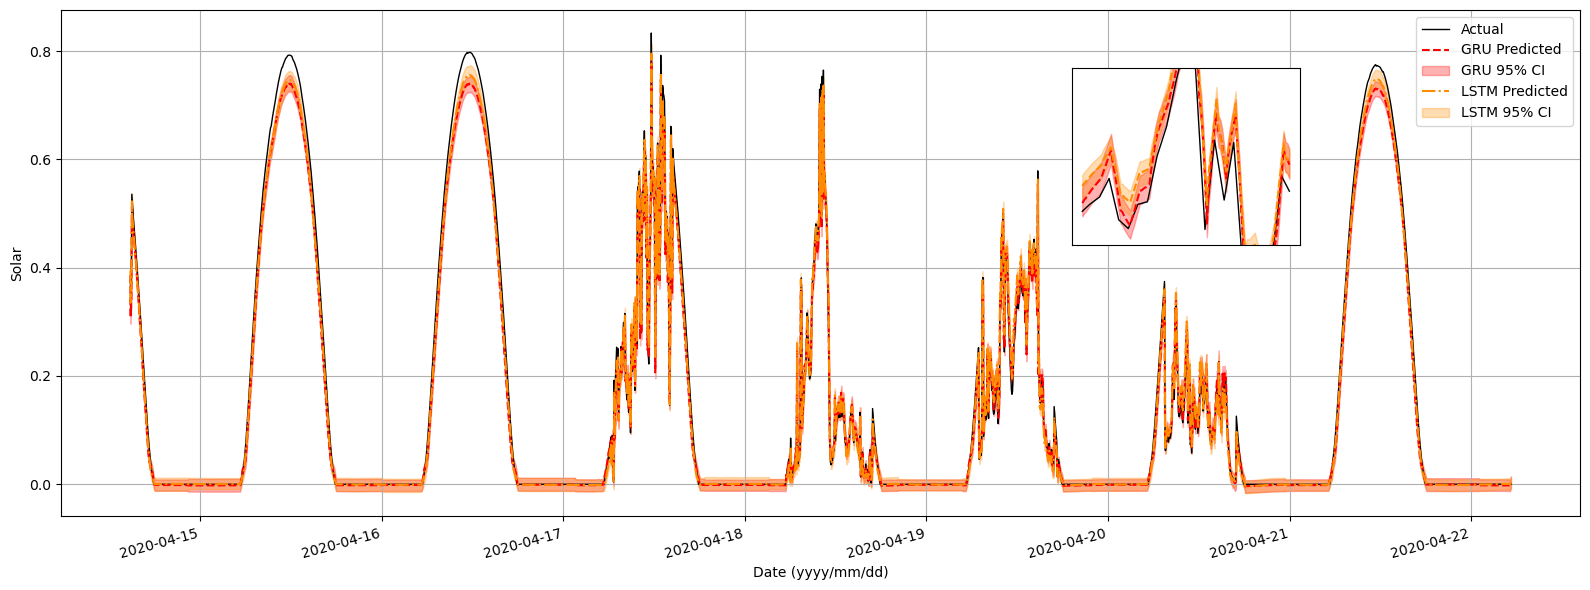

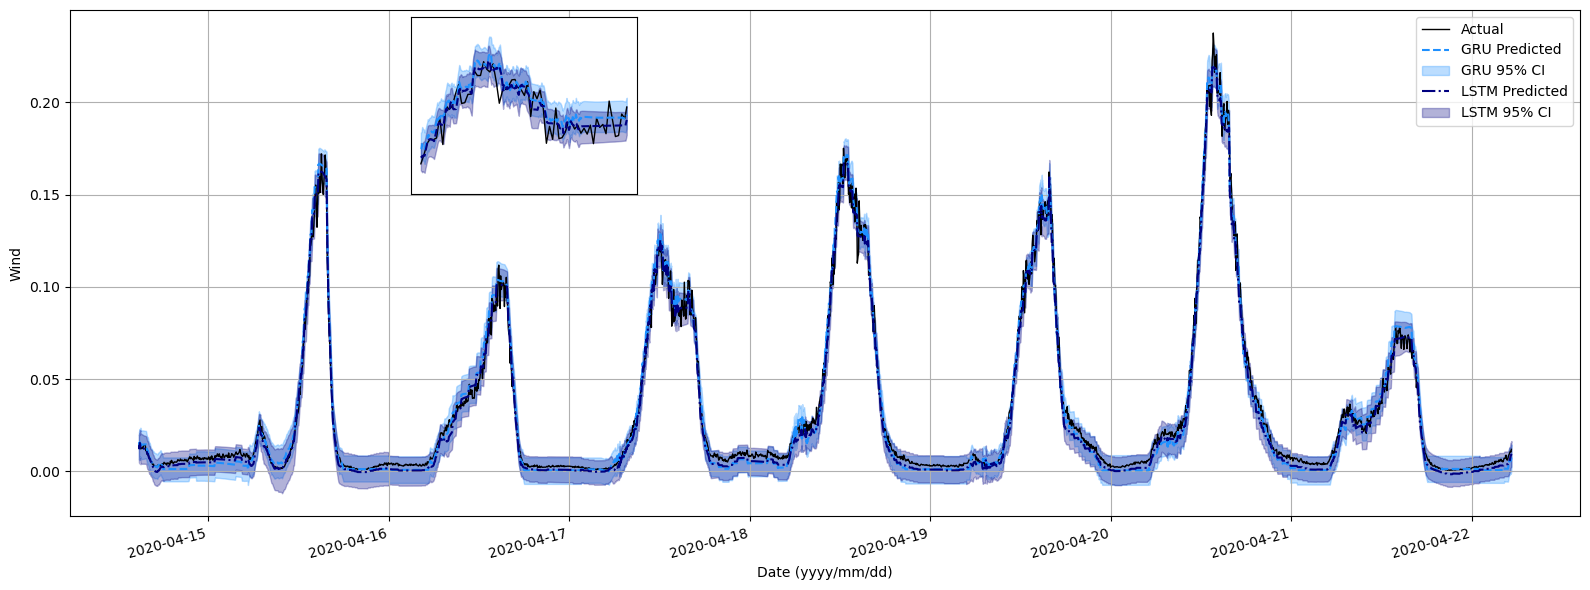

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes  # for inset

def load_csv_arrays(csv_path):
    """
    Reads a CSV with columns:
      'True Solar', 'True Wind',
      'Predicted Mean Solar', 'Predicted Mean Wind',
      'Lower CI Solar', 'Lower CI Wind',
      'Upper CI Solar', 'Upper CI Wind'
    Returns:
      trues  : (T, 2) array
      preds  : (T, 2) array
      lower  : (T, 2) array
      upper  : (T, 2) array
    """
    df = pd.read_csv(csv_path)
    trues = df[['True Solar', 'True Wind']].to_numpy()
    preds = df[['Predicted Mean Solar', 'Predicted Mean Wind']].to_numpy()
    lower = df[['Lower CI Solar', 'Lower CI Wind']].to_numpy()
    upper = df[['Upper CI Solar', 'Upper CI Wind']].to_numpy()
    return trues, preds, lower, upper

def get_test_datetimes(full_csv_path, test_fraction=0.6):
    """
    Reads the full CSV (with a 'time' column) and returns a NumPy array of
    datetimes corresponding to the test set, which is assumed to be the
    last `test_fraction` fraction of rows.
    """
    df_full = pd.read_csv(full_csv_path, parse_dates=['time'])
    total_rows = len(df_full)
    start_idx = int((1.0 - test_fraction) * total_rows)
    test_times = df_full['time'].iloc[start_idx:].to_numpy()
    return test_times

def plot_gru_vs_lstm_with_dates(
    full_csv_path,
    gru_csv,
    lstm_csv,
    start: int = 0,
    end: int = None,
    color_gru_solar: str = 'orangered',
    color_gru_wind: str  = 'dodgerblue',
    color_lstm_solar: str = 'magenta',
    color_lstm_wind: str  = 'teal'
):
    """
    Plots GRU vs. LSTM predictions (with 95% CI) on the same axes for Solar and Wind,
    over a specified index interval [start:end), using real timestamps on the x‐axis.
    Adds a zoomed inset of the final 25% of the plotted interval.

    Arguments:
      full_csv_path    : path to the original CSV containing the 'time' column.
      gru_csv          : path to vGRUTest.csv (predictions and CI).
      lstm_csv         : path to vLSTMTest.csv.
      start            : start index (inclusive) within the test set.
      end              : end index (exclusive) within the test set. If None, uses all test rows.
      color_gru_solar  : color for GRU–Solar (mean & CI).
      color_gru_wind   : color for GRU–Wind (mean & CI).
      color_lstm_solar : color for LSTM–Solar (mean & CI).
      color_lstm_wind  : color for LSTM–Wind (mean & CI).
    """
    # 1) Load full timestamps for the test set
    test_datetimes = get_test_datetimes(full_csv_path, test_fraction=0.6)

    # 2) Load GRU/LSTM arrays
    trues_gru, preds_gru, lower_gru, upper_gru     = load_csv_arrays(gru_csv)
    trues_lstm, preds_lstm, lower_lstm, upper_lstm = load_csv_arrays(lstm_csv)

    # Ensure indices do not exceed length
    total_test_len = len(trues_gru)
    if end is None or end > total_test_len:
        end = total_test_len

    # 3) Slice to [start:end)
    trues_slice       = trues_gru[start:end]
    preds_gru_slice   = preds_gru[start:end]
    lower_gru_slice   = lower_gru[start:end]
    upper_gru_slice   = upper_gru[start:end]
    preds_lstm_slice  = preds_lstm[start:end]
    lower_lstm_slice  = lower_lstm[start:end]
    upper_lstm_slice  = upper_lstm[start:end]

    # Corresponding datetime slice for x-axis
    times_slice = test_datetimes[start:end]
    labels = ['Solar', 'Wind']

    for i, lab in enumerate(labels):
        # Pick colors for this output
        if i == 0:  # Solar
            c_gru  = color_gru_solar
            c_lstm = color_lstm_solar
        else:       # Wind
            c_gru  = color_gru_wind
            c_lstm = color_lstm_wind

        plt.figure(figsize=(16, 6))

        # Plot ground truth (black)
        plt.plot(times_slice, trues_slice[:, i], 'k', label='Actual', linewidth=1)

        # GRU predicted mean + CI
        plt.plot(
            times_slice, preds_gru_slice[:, i],
            color=c_gru, linestyle='--', label='GRU Predicted'
        )
        plt.fill_between(
            times_slice,
            lower_gru_slice[:, i],
            upper_gru_slice[:, i],
            color=c_gru,
            alpha=0.3,
            label='GRU 95% CI'
        )

        # LSTM predicted mean + CI
        plt.plot(
            times_slice, preds_lstm_slice[:, i],
            color=c_lstm, linestyle='-.', label='LSTM Predicted'
        )
        plt.fill_between(
            times_slice,
            lower_lstm_slice[:, i],
            upper_lstm_slice[:, i],
            color=c_lstm,
            alpha=0.3,
            label='LSTM 95% CI'
        )

        # Format x-axis as dates
        ax = plt.gca()
        ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
        plt.xticks(rotation=15, ha='right')

        plt.xlabel('Date (yyyy/mm/dd)')
        plt.ylabel(lab)
        plt.grid()
        plt.legend(loc='upper right')

        # --- Add inset showing final 25% of the interval ---
        N = len(times_slice)

        # Create an inset axes in the top-left corner
        if lab == 'Solar':
            inset_start = int(0.76 * N)
            inset_end   = int(0.77 * N)
            axins = inset_axes(ax, width="50%", height="70%", bbox_to_anchor=(0.52,0.4,0.3,0.5), bbox_transform=ax.transAxes)
        else:
            inset_start = int(0.37 * N)
            inset_end   = int(0.4 * N)
            axins = inset_axes(ax, width="50%", height="70%", bbox_to_anchor=(0.08,0.5,0.3,0.5), bbox_transform=ax.transAxes)
        # Plot the zoomed portion
        axins.plot(
            times_slice[inset_start:inset_end], trues_slice[inset_start: inset_end, i],
            'k', linewidth=1
        )
        axins.plot(
            times_slice[inset_start:inset_end], preds_gru_slice[inset_start:inset_end, i],
            color=c_gru, linestyle='--'
        )
        axins.fill_between(
            times_slice[inset_start:inset_end],
            lower_gru_slice[inset_start:inset_end, i],
            upper_gru_slice[inset_start:inset_end, i],
            color=c_gru,
            alpha=0.3
        )
        axins.plot(
            times_slice[inset_start:inset_end], preds_lstm_slice[inset_start:inset_end, i],
            color=c_lstm, linestyle='--'
        )
        axins.fill_between(
            times_slice[inset_start:inset_end],
            lower_lstm_slice[inset_start:inset_end, i],
            upper_lstm_slice[inset_start:inset_end, i],
            color=c_lstm,
            alpha=0.3
        )

        axins.set_xticks([])
        axins.set_yticks([])
        if lab == 'Solar':
            axins.set_ylim(0.1,0.25)
        else:
            axins.set_ylim(0.05,0.15)
        plt.tight_layout()
        plt.savefig(f"LSTM_GRU_PSML_{lab}.png", dpi=300, bbox_inches='tight')
        plt.show()

start_month = 13
plot_gru_vs_lstm_with_dates(
    full_csv_path='../../dataset/PSML.csv',
    gru_csv='vGRUTest.csv',
    lstm_csv='vLSTMTest.csv',
    start=start_month*43_800,
    end=start_month*43_800 + 10950,
    color_gru_solar='red',
    color_gru_wind='dodgerblue',
    color_lstm_solar='darkorange',
    color_lstm_wind='navy'
)